# Politicians Network — Data Collection

Builds a **popularity-ranked** network of modern politicians (relevant after 1980).


In [45]:
import requests
import time
import json
import re
import pandas as pd
from collections import defaultdict
from concurrent.futures import ThreadPoolExecutor, as_completed
from datetime import datetime, timedelta
from tqdm import tqdm
import threading
import random


## 1 — Shared session & constants

In [46]:
S = requests.Session()
S.headers.update({"User-Agent": "PoliticiansNetwork/1.0 (kerem.ozemre@icloud.com)"})

BASE_WIKI  = "https://en.wikipedia.org/w/api.php"
SPARQL_URL = "https://query.wikidata.org/sparql"

SKIP_PREFIXES = ("Special:", "Main_Page", "Wikipedia:", "Help:", "File:", "Portal:")


def get_with_retry(url, params=None, session=S, max_retries=6):
    """GET with exponential backoff on 429 / 5xx."""
    for attempt in range(max_retries):
        try:
            r = session.get(url, params=params, timeout=30)
            if r.status_code == 429:
                wait = 2 ** attempt + random.uniform(0.5, 1.5)
                print(f"  Rate-limited, waiting {wait:.1f}s…")
                time.sleep(wait)
                continue
            r.raise_for_status()
            return r
        except requests.RequestException as e:
            if attempt == max_retries - 1:
                raise RuntimeError(f"Failed after {max_retries} retries: {url}") from e
            time.sleep(2 ** attempt)
    raise RuntimeError(f"Failed after {max_retries} retries: {url}")


## 2 — SPARQL executor & helpers

In [47]:
SESSION = requests.Session()
SESSION.headers.update({"User-Agent": "WikidataResearchBot/1.0 (kerem.ozemre@icloud.com)"})


def run_sparql(query, retries=5, base_sleep=1.5):
    for attempt in range(retries):
        try:
            r = SESSION.post(
                SPARQL_URL,
                data={"query": query},
                headers={"Accept": "application/json",
                         "User-Agent": "WikidataResearchBot/1.0"},
                timeout=60,
            )
            if r.status_code == 429:
                time.sleep(base_sleep * (2 ** attempt))
                continue
            r.raise_for_status()
            return r.json()
        except Exception as e:
            if attempt == retries - 1:
                raise RuntimeError(f"SPARQL failed: {e}")
            time.sleep(base_sleep * (2 ** attempt))
    raise RuntimeError("SPARQL query failed after retries")


def chunked(lst, size):
    for i in range(0, len(lst), size):
        yield lst[i:i + size]


def parse_wikidata_date(raw):
    """Extract YYYY-MM-DD from a Wikidata timestamp string."""
    if not raw:
        return None
    m = re.match(r"[+-]?(\d{4}-\d{2}-\d{2})", raw)
    return m.group(1) if m else None


def extract_qid(uri):
    return uri.split("/")[-1]


## 3 — Popularity-ranked seed fetcher

Queries Wikidata for politicians ordered by **sitelink count** — the number of Wikipedia
language editions that cover them. This is the best available proxy for global notability
without hitting the pageviews API.

Filters: human (`P31=Q5`), politician (`P106=Q82955`), born ≤ 1970,
alive or died ≥ 1980.  
Remove `wdt:P27 wd:Q30` to go global instead of US-only.


In [48]:
def make_seed_query(limit=500, offset=0):
    return f"""
    SELECT DISTINCT ?person (COUNT(?sitelink) AS ?links) WHERE {{
      ?person wdt:P31 wd:Q5 ;
              wdt:P106 wd:Q82955 .

      ?person p:P39 ?stmt .
      ?stmt ps:P39 ?office .
      ?office wdt:P17 wd:Q30 .          # office belongs to the United States

      OPTIONAL {{ ?person wdt:P569 ?birth. }}
      OPTIONAL {{ ?person wdt:P570 ?death. }}

      FILTER(
        BOUND(?birth) && YEAR(?birth) <= 1970
        && ( !BOUND(?death) || YEAR(?death) >= 1980 )
      )

      ?sitelink schema:about ?person .
    }}
    GROUP BY ?person
    ORDER BY DESC(?links)
    LIMIT {limit}
    OFFSET {offset}
    """


def get_popular_politician_ids(max_seeds=800, page_size=500):
    """
    Return QID URI list for the most cross-wiki-covered politicians,
    paginating until max_seeds is reached or results are exhausted.
    page_size kept at 500 — GROUP BY + ORDER BY queries time out above ~500.
    """
    ids    = []
    offset = 0

    while len(ids) < max_seeds:
        query    = make_seed_query(limit=page_size, offset=offset)
        data     = run_sparql(query)
        bindings = data["results"]["bindings"]
        if not bindings:
            break
        batch = [b["person"]["value"] for b in bindings]
        ids.extend(batch)
        print(f"  Collected {len(ids)} seeds…")
        offset += page_size
        time.sleep(2)   # GROUP BY queries are heavier — be polite

    return ids[:max_seeds]


## 4 — Label fetcher

Resolves QIDs → English Wikipedia article titles.
The link-walker needs these titles to look up pages.
Also used to refresh titles for neighbor nodes discovered in expansion passes.


In [49]:
def fetch_labels(qids, batch_size=400):
    """
    Fetch English Wikipedia titles for a list of QIDs.
    Returns {wikipedia_title: qid} for QIDs that have an enwiki article.
    """
    name_to_qid = {}

    for chunk in tqdm(list(chunked(qids, batch_size)), desc="Fetching labels"):
        values = " ".join(f"wd:{q}" for q in chunk)
        query  = f"""
        SELECT ?person ?article WHERE {{
          VALUES ?person {{ {values} }}
          ?article schema:about ?person ;
                   schema:isPartOf <https://en.wikipedia.org/> .
        }}
        """
        data = run_sparql(query)
        for b in data["results"]["bindings"]:
            qid   = b["person"]["value"].split("/")[-1]
            title = (b["article"]["value"]
                     .replace("https://en.wikipedia.org/wiki/", "")
                     .replace("_", " "))
            name_to_qid[title] = qid
        time.sleep(1)

    print(f"  {len(name_to_qid)} QIDs have an English Wikipedia article")
    return name_to_qid


## 5 — Wikipedia link-walker (degree computation)

In [50]:
# ── Rate-limit governor ────────────────────────────────────────────────────────
_WIKI_SEM      = threading.Semaphore(4)
_BACKOFF_LOCK  = threading.Lock()
_BACKOFF_UNTIL = 0.0

def _wait_for_backoff():
    with _BACKOFF_LOCK:
        target = _BACKOFF_UNTIL
    remaining = target - time.monotonic()
    if remaining > 0:
        time.sleep(remaining)

def _set_backoff(seconds):
    global _BACKOFF_UNTIL
    with _BACKOFF_LOCK:
        _BACKOFF_UNTIL = max(_BACKOFF_UNTIL, time.monotonic() + seconds)


# ── Fetch all outgoing links from a Wikipedia page ────────────────────────────
def get_page_links(title):
    session = requests.Session()
    session.headers.update({"User-Agent": "PoliticiansNetwork/1.0 (kerem.ozemre@icloud.com)"})

    links  = []
    params = {
        "action": "query", "titles": title, "prop": "links",
        "pllimit": "500", "plnamespace": "0", "format": "json",
    }
    while True:
        r    = get_with_retry(BASE_WIKI, params=params, session=session)
        data = r.json()
        for page in data.get("query", {}).get("pages", {}).values():
            for lk in page.get("links", []):
                links.append(lk["title"])
        cont = data.get("continue", {})
        if not cont:
            break
        params["plcontinue"] = cont["plcontinue"]
        time.sleep(0.2)
    return links


# ── Thread-safe caches ─────────────────────────────────────────────────────────
_title_lock = threading.Lock()
_qid_lock   = threading.Lock()

def resolve_titles_to_qids_cached(titles, cache, batch_size=50):
    with _title_lock:
        uncached = [t for t in titles if t not in cache]
    for i in range(0, len(uncached), batch_size):
        batch  = uncached[i:i + batch_size]
        params = {
            "action": "query", "titles": "|".join(batch),
            "prop": "pageprops", "ppprop": "wikibase_item", "format": "json",
        }
        r     = get_with_retry(BASE_WIKI, params=params)
        pages = r.json()["query"]["pages"]
        norm  = {n["from"]: n["to"] for n in r.json()["query"].get("normalized", [])}
        result = {}
        for page in pages.values():
            qid    = page.get("pageprops", {}).get("wikibase_item")
            ptitle = page.get("title", "")
            result[ptitle] = qid
        for orig, norm_title in norm.items():
            if norm_title in result:
                result[orig] = result[norm_title]
        with _title_lock:
            cache.update(result)
        time.sleep(0.1)
    with _title_lock:
        return {t: cache.get(t) for t in titles}


def filter_politician_qids_cached(qids, cache, batch_size=200):
    with _qid_lock:
        unchecked = [q for q in qids if q not in cache["seen"]]
    for i in range(0, len(unchecked), batch_size):
        batch  = unchecked[i:i + batch_size]
        values = " ".join(f"wd:{q}" for q in batch)
        query  = f"""
        SELECT ?person WHERE {{
          VALUES ?person {{ {values} }}
          ?person wdt:P106 wd:Q82955 .

          # Must have held a US office
          ?person p:P39 ?stmt .
          ?stmt ps:P39 ?office .
          ?office wdt:P17 wd:Q30 .

          # Same date filter as seeds
          OPTIONAL {{ ?person wdt:P569 ?birth. }}
          OPTIONAL {{ ?person wdt:P570 ?death. }}
          FILTER(
            BOUND(?birth) && YEAR(?birth) <= 1970
            && ( !BOUND(?death) || YEAR(?death) >= 1980 )
          )
        }}
        """
        data  = run_sparql(query)
        found = [item["person"]["value"].split("/")[-1]
                 for item in data["results"]["bindings"]]
        with _qid_lock:
            cache["politicians"].update(found)
            cache["seen"].update(batch)
        time.sleep(0.5)
    with _qid_lock:
        return cache["politicians"]


# ── Serial walker with adaptive throttle ──────────────────────────────────────
def compute_politician_degrees(name_to_qid, title_qid_cache=None, politician_cache=None):
    """
    Walk Wikipedia pages for each politician in name_to_qid.
    Returns (degrees, neighbours) dicts keyed by QID.
    Caches are shared across calls so repeated QIDs are only looked up once.
    """
    if title_qid_cache is None:
        title_qid_cache = {}
    if politician_cache is None:
        politician_cache = {"seen": set(), "politicians": set()}

    degrees   = {}
    neighbors = {}
    delay     = 0.3

    for idx, (title, qid) in enumerate(tqdm(name_to_qid.items(), desc="Walking pages"), 1):
        linked_titles = []
        for attempt in range(6):
            try:
                linked_titles = get_page_links(title)
                delay = max(0.1, delay * 0.95)
                break
            except Exception as e:
                if "429" in str(e):
                    delay = min(30, delay * 2)
                    print(f"  429 on '{title}' — slowing to {delay:.1f}s")
                    time.sleep(delay)
                elif attempt == 5:
                    print(f"  Giving up on '{title}': {e}")
                    break
                else:
                    time.sleep(2 ** attempt)

        if not linked_titles:
            degrees[qid]   = 0
            neighbors[qid] = []
        else:
            t2q            = resolve_titles_to_qids_cached(linked_titles, title_qid_cache)
            linked_qids    = [q for q in t2q.values() if q]
            pol_set        = filter_politician_qids_cached(linked_qids, politician_cache) if linked_qids else set()
            pol_qids       = [q for q in linked_qids if q in pol_set]
            degrees[qid]   = len(pol_qids)
            neighbors[qid] = pol_qids

        time.sleep(delay)

        if idx % 50 == 0:
            print(f"  [{idx}/{len(name_to_qid)}] delay={delay:.2f}s | "
                  f"title cache={len(title_qid_cache)} | "
                  f"qid cache={len(politician_cache['seen'])}")

    return degrees, neighbors


## 6 — Feature fetcher

In [51]:
def make_details_query(person_ids):
    values = " ".join(f"wd:{p.split('/')[-1]}" for p in person_ids)
    return f"""
    SELECT
      ?person ?personLabel ?positionLabel
      ?start ?end ?natLabel ?birth ?death
      ?partyLabel ?genderLabel ?educationLabel ?stateLabel ?article
    WHERE {{
      VALUES ?person {{ {values} }}

      ?person p:P39 ?statement .
      ?statement ps:P39 ?position .
      OPTIONAL {{ ?statement pq:P580 ?start. }}
      OPTIONAL {{ ?statement pq:P582 ?end. }}

      OPTIONAL {{ ?person wdt:P27 ?nat. }}
      OPTIONAL {{ ?person wdt:P569 ?birth. }}
      OPTIONAL {{ ?person wdt:P570 ?death. }}
      OPTIONAL {{ ?person wdt:P102 ?party. }}
      OPTIONAL {{ ?person wdt:P21 ?gender. }}
      OPTIONAL {{ ?person wdt:P69 ?education. }}
      OPTIONAL {{
        ?person wdt:P19 ?birthPlace .
        ?birthPlace wdt:P131* ?state .
      }}
      OPTIONAL {{
        ?article schema:about ?person ;
                 schema:isPartOf <https://en.wikipedia.org/> .
      }}

      SERVICE wikibase:label {{ bd:serviceParam wikibase:language "en". }}
    }}
    """


def fetch_details(person_ids, batch_size=50):
    rows = []
    for i, chunk in enumerate(chunked(person_ids, batch_size), 1):
        print(f"  Details batch {i}/{-(-len(person_ids)//batch_size)} ({len(chunk)} people)")
        data = run_sparql(make_details_query(chunk))
        for item in data["results"]["bindings"]:
            rows.append({
                "wikidata":      extract_qid(item["person"]["value"]),
                "name":          item.get("personLabel",   {}).get("value"),
                "position":      item.get("positionLabel", {}).get("value"),
                "start":         parse_wikidata_date(item.get("start",  {}).get("value")),
                "end":           parse_wikidata_date(item.get("end",    {}).get("value")),
                "nationality":   item.get("natLabel",      {}).get("value"),
                "birth_date":    parse_wikidata_date(item.get("birth",  {}).get("value")),
                "death_date":    parse_wikidata_date(item.get("death",  {}).get("value")),
                "party":         item.get("partyLabel",    {}).get("value"),
                "gender":        item.get("genderLabel",   {}).get("value"),
                "education":     item.get("educationLabel",{}).get("value"),
                "state":         item.get("stateLabel",    {}).get("value"),
                "wikipedia_url": item.get("article",       {}).get("value"),
            })
        time.sleep(1.5)
    return rows


## 7 — Dedup & party helpers

In [52]:
POSITION_RANK = {
    "President of the United States": 1,
    "Vice President of the United States": 2,
    "Secretary of State": 3,
    "Secretary of Defense": 4,
    "Attorney General of the United States": 5,
    "Secretary of the Treasury": 6,
    "White House Chief of Staff": 7,
    "United States Senator": 8,
    "Speaker of the House of Representatives": 9,
    "House Majority Leader": 10,
    "Senate Majority Leader": 10,
    "United States Representative": 11,
    "Governor": 12,
    "Ambassador": 13,
    "Lieutenant Governor": 14,
    "State Senator": 15,
    "State Representative": 16,
    "Mayor": 17,
}

def position_priority(pos):
    if pos is None:
        return 999
    if pos in POSITION_RANK:
        return POSITION_RANK[pos]
    for key, rank in POSITION_RANK.items():
        if key.lower() in pos.lower():
            return rank
    return 998


def simplify_party(p):
    if p is None:
        return None
    if "Democratic" in p:
        return "Democrat"
    if "Republican" in p:
        return "Republican"
    return "Other"


def dedup_df(df):
    """Keep the most prestigious position per unique wikidata QID."""
    df = df.copy()
    df["position_rank"] = df["position"].apply(position_priority)
    df = (df.sort_values("position_rank")
            .drop_duplicates(subset=["wikidata"], keep="first")
            .drop(columns=["position_rank"]))
    df["party_simple"] = df["party"].apply(simplify_party)
    return df


## 8 — End-to-end pipeline

```
run_pipeline(max_seeds=800, expand_neighbors=True)
```

| `expand_neighbors` | Expected nodes |
|---|---|
| `False` (pass 1 only) | ~2,500–3,500 |
| `True`  (pass 1 + 2)  | ~6,000–10,000 |

Shared caches are passed between expansion passes so no QID is resolved twice.
`fetch_details` runs **once** at the very end on the full combined node set.


In [54]:
def run_pipeline(max_seeds=800, expand_neighbors=False):
    # ── Phase 1: popularity-ranked seeds ──────────────────────────────────────
    print("=" * 60)
    print("Phase 1 — Fetching popularity-ranked seed IDs…")
    seed_uris = get_popular_politician_ids(max_seeds=max_seeds)
    seed_qids = {extract_qid(u) for u in seed_uris}
    print(f"  Unique seeds: {len(seed_qids)}")

    print("\nFetching Wikipedia titles for seeds…")
    seed_titles = fetch_labels(list(seed_qids))
    print(f"  Seeds with enwiki article: {len(seed_titles)}")

    # Shared caches — reused across both expansion passes
    title_qid_cache  = {}
    politician_cache = {"seen": set(), "politicians": set()}

    # ── Phase 2: link-walk seeds ───────────────────────────────────────────────
    print("\n" + "=" * 60)
    print("Phase 2 — Link-walking seed pages…")
    degrees, neighbours = compute_politician_degrees(
        seed_titles, title_qid_cache, politician_cache
    )

    neighbor_qids_1 = {q for conns in neighbours.values() for q in conns} - seed_qids
    all_qids        = seed_qids | neighbor_qids_1
    print(f"  Seeds              : {len(seed_qids)}")
    print(f"  New from pass 1    : {len(neighbor_qids_1)}")
    print(f"  Total after pass 1 : {len(all_qids)}")

    # ── Phase 3: optional second expansion pass ────────────────────────────────
    if expand_neighbors and neighbor_qids_1:
        print("\n" + "=" * 60)
        print("Phase 3 — Link-walking neighbor pages…")
        neighbor_titles = fetch_labels(list(neighbor_qids_1))
        degrees_2, neighbours_2 = compute_politician_degrees(
            neighbor_titles, title_qid_cache, politician_cache
        )

        neighbor_qids_2 = {q for conns in neighbours_2.values() for q in conns} - all_qids
        all_qids       |= neighbor_qids_2
        print(f"  New from pass 2    : {len(neighbor_qids_2)}")
        print(f"  Total after pass 2 : {len(all_qids)}")

        degrees.update(degrees_2)
        neighbours.update(neighbours_2)

    # ── Link-walk the non-seed neighbors too ──────────────────────────────────
    # Seeds already have degrees/neighbours from the walk above.
    # Non-seed nodes were only *discovered* as neighbors — we haven't walked
    # their pages yet, so we do that now to get their connections too.
    non_seed_qids   = all_qids - seed_qids
    non_seed_titles = fetch_labels(list(non_seed_qids))
    print(f"\nLink-walking {len(non_seed_titles)} non-seed pages for their connections…")
    degrees_ns, neighbours_ns = compute_politician_degrees(
        non_seed_titles, title_qid_cache, politician_cache
    )
    # Only add — don't overwrite seeds that were already walked
    for qid, deg in degrees_ns.items():
        if qid not in degrees:
            degrees[qid]   = deg
            neighbours[qid] = neighbours_ns[qid]

    # ── Phase 4: fetch features for everyone ──────────────────────────────────
    print("\n" + "=" * 60)
    print(f"Phase 4 — Fetching features for all {len(all_qids)} politicians…")
    all_uris = [f"http://www.wikidata.org/entity/{q}" for q in all_qids]
    rows     = fetch_details(all_uris)

    df = pd.DataFrame(rows)
    df = dedup_df(df)
    df["degree"]      = df["wikidata"].map(degrees)
    df["connections"] = df["wikidata"].map(neighbours).apply(
        lambda x: x if isinstance(x, list) else []
    )
    df["is_seed"] = df["wikidata"].isin(seed_qids)

    # ── Save edges to JSON ─────────────────────────────────────────────────────
    import json
    node_set     = set(df["wikidata"])
    clean_edges  = {
        qid: [n for n in conns if n in node_set]
        for qid, conns in neighbours.items()
        if qid in node_set
    }
    with open("politician_edges.json", "w") as f:
        json.dump(clean_edges, f)
    print(f"Saved → politician_edges.json  "
          f"({len(clean_edges)} nodes, "
          f"{sum(len(v) for v in clean_edges.values())} total edge entries)")

    # ── Save node CSV ──────────────────────────────────────────────────────────
    df.to_csv("politicians_network_nodes.csv", index=False)
    print(f"Saved → politicians_network_nodes.csv  ({len(df)} rows)")

    n_seeds = df["is_seed"].sum()
    print(f"\n{'=' * 60}")
    print(f"Pipeline complete.")
    print(f"  Seed nodes     : {n_seeds}")
    print(f"  Expanded nodes : {len(df) - n_seeds}")
    print(f"  Total nodes    : {len(df)}")
    return df


df = run_pipeline(max_seeds=200, expand_neighbors=False)


Phase 1 — Fetching popularity-ranked seed IDs…
  Collected 500 seeds…
  Unique seeds: 200

Fetching Wikipedia titles for seeds…


Fetching labels: 100%|██████████| 1/1 [00:01<00:00,  1.70s/it]


  200 QIDs have an English Wikipedia article
  Seeds with enwiki article: 200

Phase 2 — Link-walking seed pages…


Walking pages:  25%|██▌       | 50/200 [05:57<11:59,  4.79s/it] 

  [50/200] delay=0.10s | title cache=27955 | qid cache=24049


...

  [3850/3907] delay=0.10s | title cache=164116 | qid cache=128116


Walking pages: 100%|█████████▉| 3900/3907 [2:19:58<00:10,  1.43s/it]

  [3900/3907] delay=0.10s | title cache=164893 | qid cache=128686


Walking pages: 100%|██████████| 3907/3907 [2:20:07<00:00,  2.15s/it]



Phase 4 — Fetching features for all 4107 politicians…
  Details batch 1/83 (50 people)
  Details batch 2/83 (50 people)
  Details batch 3/83 (50 people)
  Details batch 4/83 (50 people)
  Details batch 5/83 (50 people)
  Details batch 6/83 (50 people)
  Details batch 7/83 (50 people)
  Details batch 8/83 (50 people)
  Details batch 9/83 (50 people)
  Details batch 10/83 (50 people)
  Details batch 11/83 (50 people)
  Details batch 12/83 (50 people)
  Details batch 13/83 (50 people)
  Details batch 14/83 (50 people)
  Details batch 15/83 (50 people)
  Details batch 16/83 (50 people)
  Details batch 17/83 (50 people)
  Details batch 18/83 (50 people)
  Details batch 19/83 (50 people)
  Details batch 20/83 (50 people)
  Details batch 21/83 (50 people)
  Details batch 22/83 (50 people)
  Details batch 23/83 (50 people)
  Details batch 24/83 (50 people)
  Details batch 25/83 (50 people)
  Details batch 26/83 (50 people)
  Details batch 27/83 (50 people)
  Details batch 28/83 (50 people)
  

## 9 — Save

In [ ]:
if not df.empty:
    print(f"Shape: {df.shape}")
    print(df.head(20).to_string())
else:
    print("Nothing to save — DataFrame is empty.")


Saved → politicians_network_nodes.csv
Shape: (4107, 17)
         wikidata                  name                                                   position       start         end    nationality  birth_date  death_date             party  gender                                          education                                            state                                       wikipedia_url party_simple  degree                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        

In [56]:
df["party"] = df["party"].apply(simplify_party)
df

,wikidata,name,position,start,end,nationality,birth_date,death_date,party,gender,education,state,wikipedia_url,party_simple,degree,connections,is_seed
270598,Q22686,Donald Trump,President of the United States,2017-01-20,2021-01-20,United States,1946-06-14,None,Republican,male,The Wharton School,Jamaica Hospital Medical Center,https://en.wikipedia.org/wiki/Donald_Trump,Republican,64,"[Q19673, Q4716651, Q7273452, Q665416, Q3793646...",True
154780,Q23685,Jimmy Carter,President of the United States,1977-01-20,1981-01-20,United States,1924-10-01,2024-12-29,Democrat,male,United States Naval Academy,Sumter County,https://en.wikipedia.org/wiki/Jimmy_Carter,Democrat,202,"[Q122841, Q319084, Q19673, Q193635, Q665416, Q...",True
113346,Q311135,Karl Rove,Senior Advisor to the President of the United ...,None,None,United States,1950-12-25,None,Republican,male,Olympus High School,Denver,https://en.wikipedia.org/wiki/Karl_Rove,Republican,83,"[Q1886056, Q504029, Q237918, Q11171, Q76, Q319...",False
23249,Q1124,Bill Clinton,President of the United States,1993-01-20,2001-01-20,United States,1946-08-19,None,Democrat,male,Hot Springs High School,Hope,https://en.wikipedia.org/wiki/Bill_Clinton,Democrat,256,"[Q319084, Q19673, Q193635, Q887125, Q292340, Q...",True
84497,Q5300923,Doug Sosnik,Senior Advisor to the President of the United ...,1998-11-07,2001-01-20,United States,1956-09-26,None,Democrat,male,Duke University,None,https://en.wikipedia.org/wiki/Doug_Sosnik,Democrat,6,"[Q1124, Q319111, Q22316, Q311135, Q453893, Q29...",False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
133801,Q4737931,Alveda King,member of the Georgia House of Representatives,1979-01-01,1983-01-01,United States,1951-01-22,None,Republican,female,Central Michigan University,United States,https://en.wikipedia.org/wiki/Alveda_King,Republican,6,"[Q959635, Q22686, Q15512904, Q310586, Q45380, ...",False
133850,Q443029,Rick Hill,member of the United States House of Represent...,None,None,United States,1946-12-30,None,Republican,male,St. Cloud State University,Itasca County,https://en.wikipedia.org/wiki/Rick_Hill,Republican,24,"[Q695870, Q4911450, Q887793, Q1126725, Q118968...",False
133408,Q1681266,James W. Symington,member of the United States House of Represent...,1973-01-03,1975-01-03,United States,1927-09-28,None,Democrat,male,Mary Institute and St. Louis Country Day School,New York,https://en.wikipedia.org/wiki/James_W._Symington,Democrat,57,"[Q548596, Q1668288, Q3917251, Q862035, Q548122...",False
133479,Q1931352,Mickey Edwards,member of the United States House of Represent...,1979-01-03,1981-01-03,United States,1937-07-12,None,Republican,male,University of Oklahoma,United States,https://en.wikipedia.org/wiki/Mickey_Edwards,Republican,53,"[Q4320649, Q76, Q2579562, Q896763, Q288402, Q1...",False


In [57]:
df.to_csv("politicians_network_nodes.csv", index=False)

In [60]:
import networkx as nx
import matplotlib.pyplot as plt

df.dropna(subset=["connections"], inplace=True)

id_to_connections = {
    k: set(v) if isinstance(v, (list, tuple, set)) else set()
    for k, v in zip(df["wikidata"], df["connections"])
}

# ── Build graph ────────────────────────────────────────────────────────────────
G = nx.Graph()

# Node attributes: store every DataFrame feature on the node
FEATURE_COLS = [
    "name", "position", "start", "end",
    "nationality", "birth_date", "death_date",
    "party", "party_simple", "gender", "education",
    "state", "degree", "wikipedia_url",
]

# Add nodes first so isolated politicians are still included
for _, row in df.iterrows():
    qid   = row["wikidata"]
    attrs = {col: row.get(col) for col in FEATURE_COLS if col in df.columns}
    G.add_node(qid, **attrs)

# Add edges
for person, conns in id_to_connections.items():
    for other in conns:
        if other in id_to_connections:
            G.add_edge(person, other)

# ── Largest connected component ────────────────────────────────────────────────
largest_cc = max(nx.connected_components(G), key=len)
G_lcc = G.subgraph(largest_cc).copy()
print(f"Nodes: {G.number_of_nodes()} | Edges: {G.number_of_edges()}")
print(f"Largest connected component: {len(largest_cc)} politicians")

# ── Quick sanity-check: node attributes ───────────────────────────────────────
sample_qid = next(iter(largest_cc))
print(f"\nSample node ({sample_qid}) attributes:")
for k, v in G_lcc.nodes[sample_qid].items():
    print(f"  {k}: {v}")


# ── Also export node table as CSV for quick inspection ────────────────────────
import pandas as pd
node_df = pd.DataFrame.from_dict(dict(G_lcc.nodes(data=True)), orient="index")
node_df.index.name = "wikidata"
node_df.to_csv("politicians_network_nodes.csv")
print("Saved → politicians_network_nodes.csv")


Nodes: 4107 | Edges: 147070
Largest connected component: 4107 politicians

Sample node (Q972641) attributes:
  name: John C. Whitehead
  position: United States Deputy Secretary of State
  start: 1985-07-09
  end: 1989-01-20
  nationality: United States
  birth_date: 1922-04-02
  death_date: 2015-02-07
  party: Republican
  party_simple: Republican
  gender: male
  education: Boys and Girls High School
  state: Evanston
  degree: 23
  wikipedia_url: https://en.wikipedia.org/wiki/John_C._Whitehead
Saved → politicians_network_nodes.csv


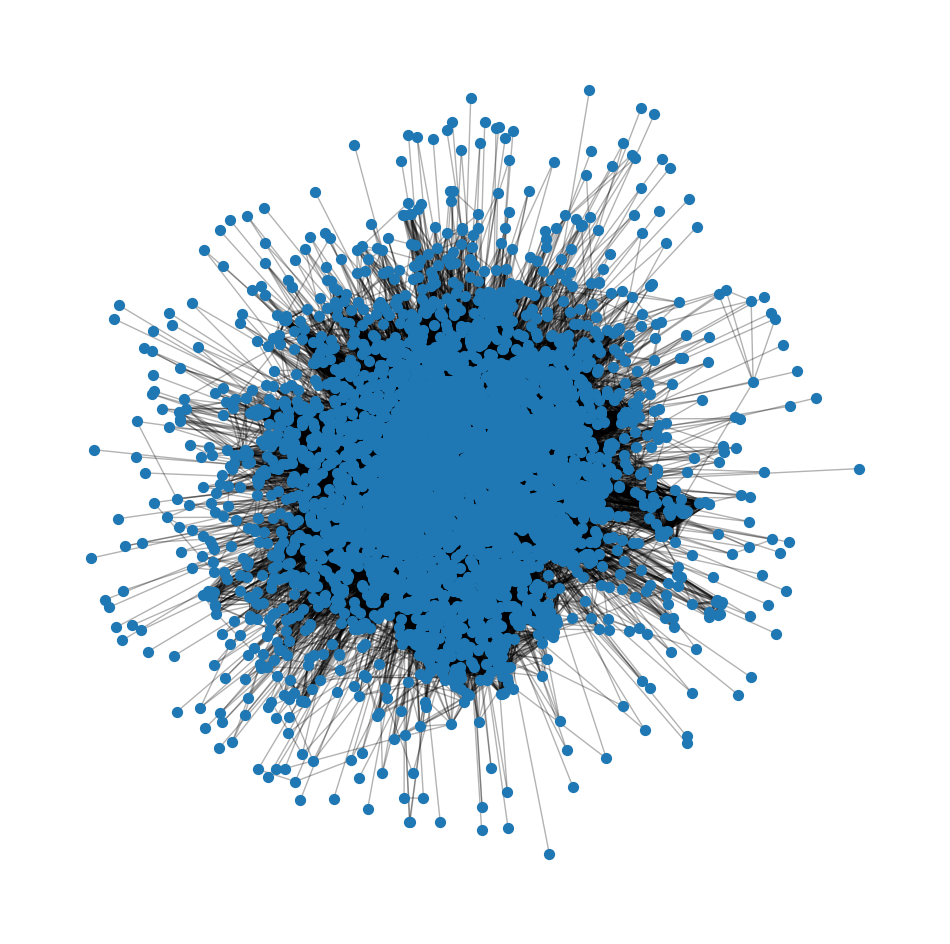

In [61]:
pos = nx.spring_layout(G_lcc, seed=42)
plt.figure(figsize=(12, 12))

nx.draw_networkx_nodes(G_lcc, pos, node_size=50)
nx.draw_networkx_edges(G_lcc, pos, alpha=0.3)

plt.axis("off")
plt.show()